# Pipeline stage 1: the search for phage-encoded acetyltransferases

### Stage 1.2: assessing annotated acetyltransferases

As only two phage-encoded acetyltransferases have been studied experimentally, most of the acetyltransferase annotations stem from automated annotation pipelines, without any validation. To increase the likelihood of acetyltransferase function of the proteins investigated in our study, we will supplement the sequence-based annotations with (computationally predicted) structure-based information. We use this approach as we expect to find mostly GCN5-related N-acetyltransferases (GNATs), which are structurally highly conserved. As such, structure should serve as good source of additional annotation evidence. 

**Goals:**
* Extract all unique annotated acetyltransferases from *Pseudomonas* infecting phages.
* Prepare necessary files for predicting protein structures of these proteins on HPC.
* Predict & inspect protein structures of these proteins.
* Prepare necessary files for analysing protein structures of these proteins on HPC.
* Assess likelihood acetyltransferase function based on predicted protein structure & similar protein structures.
* Investigate smaller-than-expected annotated acetyltransferases.

**Requires:**

*  annotated_acetyltransferases_overview.tsv stored in a_input/protein_overview/ : a tab-seperated overview of the NCBI and UniProt proteins of our phages that contain 'GNAT' and/or 'acetyltransferase' in their protein name, with each row representing a unique phage-protein pairing.
*  phage_data.tsv stored in a_input/ : a tab-seperated phage-centric overview of the virus & host taxonomic information from the Virus-Host database, summarizing all included phages (one phage per line).
*  structure prediction template files submit_vibfold.py, VIBFold.py, VIBFold_adapted_functions.py and submit.sh stored in ../templates/ : template job inputs and scripts to be modified. The [VIBFold](https://github.com/jasperzuallaert/VIBFold/tree/main) scripts are adapted from those by Zuallaert J., available under an [MIT License](https://github.com/jasperzuallaert/VIBFold/blob/main/LICENSE).
*  structure comparison template files data_foldseek_5.csv and script_foldseek_5.slurm stored in ../templates/ : template job inputs and scripts to be modified.

  
**Generates:**
* annotated_acetyltransferases_seq_matched.tsv : a tab-seperated overview of the NCBI and UniProt proteins of our phages that contain 'GNAT' and/or 'acetyltransferase' in their protein name, with each row representing one unique phage-protein pair. It extends the information stored in the file annotated_acetyltransferases_overview.tsv, by (i) providing NCBI protein unique identifiers for each protein in the table and (ii) indicating identical protein sequences across the table. The latter helps to link together proteins, as we will only run structure predictions for each unique sequence, and so identical sequences identified in different phages will be predicted only once instead of once per phage. Column 'modeled_identical_ncbi_protein_uid' indicates the protein unique identifier of the protein selected for structure prediction.
* assessed_annotated_acetyltransferases.tsv : a tab-seperated overview of the NCBI and UniProt proteins of our phages that (i) contain 'GNAT' or 'acetyltransferase' in their protein name and (ii) have a structure that matches to proteins annotated as 'acetyltransferase' in either the PDB or the AlphaFold database, with each row representing one unique phage-protein pair (column names as before, with the addition of binary column "elongated", indicating updated protein entries for which earlier start codons were identified). It is thus a cleaned out version of file annotated_acetyltransferases_seq_matched.tsv, following removal of proteins deemed unlikely to be acetyltransferases.
* in folder structure_prediction:
    * in folder fastas:
        * ncbi_uid_PROTEIN.fasta : protein fasta file for every unique (based on sequence) annotated acetyltransferase, identifiable through its NCBI unique identifier
    * submit_vibfold_ncbi_uid_PROTEIN.py: python script to submit VIBFold job for specific protein, identifiable through its NCBI unique identifier
    * submit.sh, VIBFold.py, VIBFold_adapted_functions.py: python/bash scripts to submit and run VIBFold jobs
    * in folder results:
        * in folder ncbi_uid_PROTEIN:
            * 5 unrelaxed .pdb protein structures (ncbi_uid_PROTEIN_unrelaxed_rank_X_model_X_ptmx_1.pdb) and 1 relaxed .pdb protein structure (ncbi_uid_PROTEIN_relaxed.pdb): AlphaFold predicted structures
            * 3 .png files: 2 for PAE (one for all models - ncbi_uid_PROTEIN_PAE.png, one for the best model - best_PAE.png) and 1 for pLDDT/coverage (ncbi_uid_PROTEIN_coverage_lddt.png): quality metrics AlphaFold predicted structures depicted visually
            * 1 ncbi_uid_PROTEIN_info.log file
            * 1 ncbi_uid_PROTEIN_msa_ids.txt: .txt file containing all sequence identifiers of the sequences used in the MSA. Every line is a new identifier.
            * query.fasta: input sequence used for AlphaFold run
            * 1 ncbi_uid_PROTEIN_rank_1_model_X_ptmx_1.json: json file with PAE scores of the best AlphaFold prediction
    * VIBFold_ncbi_uid_PROTEIN.eXXXXX and VIBFold_ncbi_uid_PROTEIN.oXXXXX: error and output files for VIBFold jobs
* in folder structure_comparison:
    * in folder foldseek_in:
        * ncbi_uid_PROTEIN_relaxed.pdb (or ncbi_uid_PROTEIN_best.pdb for ncbi_uid_585865417) : the relaxed best AlphaFold prediction, copied from structure_prediction/results/ncbi_uid_PROTEIN
        * data_foldseek_5.csv : comma separated data file containing all parameters for the FoldSeek jobscripts. Every 3 columns represent 1 protein being  processed by FoldSeek (column 1: input PDB file, column 2: name of output for FoldSeek run against PDB, column 3: name of output for FoldSeek run against AlphaFold database). Each row contains the job parameters for 5 proteins.
        * script_foldseek_5.slurm : jobscript to run FoldSeek on the HPC
    * in folder foldseek_out:
        * ncbi_uid_PROTEIN_aln_pdb.tsv: tab-seperated output of FoldSeek run against the PDB database (v.2024-02-20)
        * ncbi_uid_PROTEIN_aln_af50m.tsv: tab-seperated output of FoldSeek run against the AlphaFold database (v.4)
        * slurm-XXXX.out : output files for FoldSeek jobs
    * in folder output_processed:
        * ncbi_uid_PROTEIN_foldseek_pdb_processed.tsv: tab-seperated output of FoldSeek run against the PDB database, after filtering on quality metrics, and with the addition of protein names
        * ncbi_uid_PROTEIN_foldseek_af50m_processed.tsv: tab-seperated output of FoldSeek run against the AlphaFold database, after filtering on quality metrics (including the self calculated pLDDT of the aligned fraction - column pLDDT_qAln), and with the addition of protein names obtained from the PDB / UniProt  (column protein_descr)
    * manual_assessment.xlsx : Excel file detailing the manual assessment of proteins with no hits containing 'acetyltransferase' in their protein name, in none of the searched structure databases (sheet assessment_no_hits), or in just one, but not both of the searched databases (sheet assessment_hits_1_database). Details the protein by its ncbi_uid (column protein), the number of hits and how these are annotated for both the PDB (column PDB_hits) and the AlphaFold database (AFdb_hits) FoldSeek search, the findings from the manual assessment of the predicted protein structure (column structure_assessment), the origin of the 'acetyltransferase' annotation of the protein (colon-seperated, first part refers to evidence in NCBI protein, second part to evidence in UniProt - column annotation_evidence) and the final decision on whether or not this protein should be considered as an acetyltransferase for downstream analysis (column final_assessment).
* in folder investigate_early_starts:
    * in folder expasy_translate:
        * in folder ncbi_uid_PROTEIN:
          * PHAGE_nt_START-STOP_nuccore_ID.fasta : input used for ExPASy translate, for PHAGE, with nucleotides taken from NCBI nuccore with accession ID, from residue START up until residue STOP
          * translate.txt  : ExPASy translate output of selected in-frame elongated variant
      * in folder structure_prediction: the exact same as for non-nested folder structure_prediction, only now for the potential elongated counterpart of two proteins (protein identifiers have had _elongated added as suffix)
      * in folder structure_comparison: the exact same as for non-nested folder structure_comparison, only now for the potential elongated counterpart of two proteins (protein identifiers have had _elongated added as suffix)    


#### General settings, imports, variables and environments

Conda environment: viral_act_assess_ann

Created with `conda create -n viral_act_assess_ann python=3.10`. Then installed `jupyter notebook`, `pandas` through conda (using command `conda install`) & `more_iterools`, `biopython`, `seaborn` through pip (command below).

In [ ]:
!pip install more-itertools

In [ ]:
!pip install biopython

In [ ]:
!pip install seaborn

In [1]:
!conda list --explicit

# This file may be used to create an environment using:
# $ conda create --name <env> --file <this file>
# platform: win-64
# created-by: conda 24.11.3
@EXPLICIT
https://conda.anaconda.org/conda-forge/noarch/ca-certificates-2025.10.5-h4c7d964_0.conda
https://conda.anaconda.org/conda-forge/noarch/python_abi-3.10-8_cp310.conda
https://conda.anaconda.org/conda-forge/noarch/tzdata-2025b-h78e105d_0.conda
https://conda.anaconda.org/conda-forge/win-64/ucrt-10.0.26100.0-h57928b3_0.conda
https://conda.anaconda.org/conda-forge/win-64/winpty-0.4.3-4.tar.bz2
https://conda.anaconda.org/conda-forge/win-64/libwinpthread-12.0.0.r4.gg4f2fc60ca-h57928b3_10.conda
https://conda.anaconda.org/conda-forge/win-64/vcomp14-14.44.35208-h818238b_32.conda
https://conda.anaconda.org/conda-forge/win-64/vc14_runtime-14.44.35208-h818238b_32.conda
https://conda.anaconda.org/conda-forge/win-64/vc-14.3-h2b53caa_32.conda
https://conda.anaconda.org/conda-forge/win-64/bzip2-1.0.8-h0ad9c76_8.conda
https://conda.anaconda.org/

In [2]:
# imports
import glob
import json
import matplotlib
import os
import requests
import shutil

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from more_itertools import batched

import Bio
from Bio import SeqIO
from Bio.PDB import *

In [3]:
# settings for requests
sess = requests.Session()
adapter = requests.adapters.HTTPAdapter(max_retries = 10)
sess.mount("https://", adapter)

In [4]:
# clear reference to different directories
pipeline_search_dir = os.getcwd()
master_dir = os.path.abspath(os.path.join(pipeline_search_dir, os.pardir, os.pardir))

In [ ]:
# creating a directory for all the data we will generate
os.mkdir(os.path.join(pipeline_search_dir, "b_assess_annotated"))

#### Goal 1: extract all unique annotated acetyltransferases from *Pseudomonas* infecting phages

The annotated acetyltransferase overview generated previously contains one line per detected acetyltransferase, based on UniProt and/or NCBI protein annotations. However, the table only matched UniProt acetyltransferases to NCBI proteins if both contained an annotation hinting at this function, hence, we do not know the NCBI protein ID for every protein in this table (as some proteins only had an annotated acetyltransferase function in UniProt and not NCBI). Here, we will make sure every protein gets its NCBI protein unique identifier assigned.

In [5]:
# reading in the acetyltransferase data
acetyltransferases = pd.read_csv(os.path.join(pipeline_search_dir, "a_input", "protein_overview", "annotated_acetyltransferases_overview.tsv"),
                                 sep = "\t", dtype = {"ncbi_protein_uid" : "Int64"})

In [6]:
# reading in the phage data
phage_data = pd.read_csv(os.path.join(pipeline_search_dir, "a_input", "phage_data.tsv"), sep = "\t")
# generating a list of our phages
phages = list(phage_data["name_taxid"]) 
# sadly some phage names are computationally challenging, containing / or . 
    # let's make a dict of those with the computationally easier alternative
annoying_phage_names_dict = {}
for phage in phages:
    if "." in phage:
        annoying_phage_names_dict[phage] = phage.replace(".", "_")
    if "/" in phage:
        annoying_phage_names_dict[phage] = phage.replace("/", "_")

In [7]:
# function for getting protein sequence through ncbi eutils
def fetch_sequence_ncbi(protein_id):
    url_fasta = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=protein&id={0}&rettype=fasta"
    # getting info
    fasta = sess.get(url_fasta.format(protein_id), stream=True).text
    seq = fasta.split("\n")
    return "".join(seq[1:-2])

In [8]:
# on the subset of data that has NaN for NCBI protein unique identifier, carry out the matching
for index, row in acetyltransferases[acetyltransferases["ncbi_protein_uid"].isna()].iterrows():
    # read in phage, sequence, length
    phage = row["name_taxid"]
    sequence = row["sequence"]
    length = row["length"]
    # dealing with annoying phage names
    if phage in annoying_phage_names_dict.keys():
        phage_path_name = annoying_phage_names_dict.get(phage)
    else:
        phage_path_name = phage
    # first, check if the protein matches one of the phage proteins of unknown function, for which we already obtained the sequence
    hypothetical_proteins_phage = pd.read_csv(os.path.join(pipeline_search_dir, "a_input", "protein_overview", f"{phage_path_name}_input_search.tsv"),
                                              sep = "\t", dtype = {"ncbi_protein_uid" : "Int64"})
    matched_proteins = hypothetical_proteins_phage[hypothetical_proteins_phage["sequence"] == sequence].reset_index(drop = True)
    if len(matched_proteins) == 1:
        acetyltransferases.loc[index, "ncbi_protein_uid"] = matched_proteins.loc[0, "ncbi_protein_uid"]
        acetyltransferases.loc[index, "ncbi_protein_name"] = matched_proteins.loc[0, "ncbi_protein_name"]
    # if not, we will try to match it to any of the other proteins - this is the case for proteins outside our imposed 100-850 AA size range
    else:
        # match to all proteins - filter out those with corrrect lengths
        all_proteins_phage = pd.read_csv(os.path.join(pipeline_search_dir, "a_input", "protein_overview", f"{phage_path_name}_protein_overview.tsv"), 
                                        sep = "\t", dtype = {"ncbi_protein_uid" : "Int64"})
        matched_proteins_length = all_proteins_phage[all_proteins_phage["ncbi_protein_length"] == length].reset_index(drop = True)
        # fetch sequences, drop duplicates, match based on sequence
        matched_proteins_length["sequence"] = matched_proteins_length.apply(lambda row: fetch_sequence_ncbi(row["ncbi_protein_uid"]), axis = 1)
        matched_proteins_length = matched_proteins_length.drop_duplicates(subset = "sequence", keep = "last")
        matched_proteins_length_seq = matched_proteins_length[matched_proteins_length["sequence"] == sequence].reset_index(drop = True)
        if len(matched_proteins_length_seq) == 1:
            acetyltransferases.loc[index, "ncbi_protein_uid"] = matched_proteins_length_seq.loc[0, "ncbi_protein_uid"]
            acetyltransferases.loc[index, "ncbi_protein_name"] = matched_proteins_length_seq.loc[0, "ncbi_protein_name"]
        else:
            print(f"No match found for entry at row {index}.")

Now, we can extract a table containing all unique acetyltransferases (unique sequences), as this will be the dataset subjected to structure prediction, with NCBI protein unique identifiers for each protein.

In [9]:
act_unique = acetyltransferases.drop_duplicates(subset = "sequence", keep = "last")

In [10]:
# let's store an overview of the matched acetylransferases
    # stating which identical protein was chosen for modelling - the last one for identical sequences
    # and stating NCBI protein IDs for all proteins
act_grouped_seq = acetyltransferases[["sequence", "ncbi_protein_uid"]].groupby("sequence", as_index = False).aggregate("last")
act_grouped_seq["modeled_identical_ncbi_protein_uid"] = act_grouped_seq["ncbi_protein_uid"]
act_overview = acetyltransferases.merge(act_grouped_seq[["sequence", "modeled_identical_ncbi_protein_uid"]], on = "sequence", how = "left")
act_overview.to_csv(os.path.join(pipeline_search_dir, "b_assess_annotated", "annotated_acetyltransferases_seq_matched.tsv"),
                   sep = "\t", index = False)

#### Goal 2: prepare necessary files for predicting protein structures of these proteins on HPC

To assess the 'acetyltransferase' annotations, we will assess whether the structures of these proteins are indeed similar to other proteins annotated as 'acetyltransferase'. Hence, we will have to predict the protein structures of these proteins, which we will do with VIBFold, a local AlphaFold installation on our HPC that mimics the ColabFold set-up (uses MMseqs to generate MSA). In order to do so, we first need to store all the sequences in seperate fasta files. Let's extract this information from the dataframe and write fasta files.

In [ ]:
# creating directories for all the data we will generate
os.mkdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction"))
os.mkdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "fastas"))

In [11]:
# create the fasta files
fasta_dir = os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_prediction", "fastas")
for index, row in act_unique.iterrows():
    uid = row["ncbi_protein_uid"]
    sequence = row["sequence"]
    with open(os.path.join(fasta_dir, f"ncbi_uid_{uid}.fasta"), "w") as file:
        file.write(f">ncbi_uid_{uid}\n")
        file.write(f"{sequence}\n")

Next, we can create the jobscripts, based on the template and the information in the dataframe.

In [12]:
# function to adapt job scripts starting from an adapted version of Jasper Zuallaert's submit_vibfold.py
def adapt_vibfold_jobscript(template, infile, outfile, length):
    # adapt runtime job based on length protein
    if length < 301:
        time = "0:45:00"
    elif length > 300 and length < 501:
        time = "1:30:00"
    else:
        time = "5:00:00"
    #read in data
    with open(template, "r") as file:
        filedata = file.read()
    #change script
    filedata = filedata.replace("inputfasta", "fastas/{0}".format(str(infile)))
    filedata = filedata.replace("walltime=48:00:00", "walltime={0}".format(time))
    #write new job script
    with open(outfile, "w") as file:
        file.write(filedata)

In [13]:
template = os.path.join(master_dir, "templates", "submit_vibfold.py")
for index, row in act_unique.iterrows():
    uid = row["ncbi_protein_uid"]
    length = row["length"]
    out_path = os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", f"submit_vibfold_ncbi_uid_{uid}.py")
    adapt_vibfold_jobscript(template, f"ncbi_uid_{uid}.fasta", out_path, length)

We also create a master script to submit all of these scripts.

In [14]:
# copy template submit script
shutil.copyfile(os.path.join(master_dir, "templates", "submit.sh"), 
                os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_prediction", "submit.sh"))
# modify template
with open(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_prediction", "submit.sh"), "a+") as submit_file:
        for file in os.listdir(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_prediction")):
            if "submit_vibfold" in file:
                string = f"python {file} \n"
                submit_file.write(string)

Now, we simply have to copy some more files to this directory, and then we can transfer the data to the HPC and submit it through the submit.sh script. 

In [15]:
shutil.copyfile(os.path.join(master_dir, "templates", "VIBFold.py"), 
                os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "VIBFold.py"))
shutil.copyfile(os.path.join(master_dir, "templates", "VIBFold_adapted_functions.py"), 
                os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "VIBFold_adapted_functions.py"))

'C:\\Users\\hanne\\OneDrive\\Documenten\\GitHub\\ACES-AcT\\pipeline\\1_search\\b_assess_annotated\\structure_prediction\\VIBFold_adapted_functions.py'

#### Goal 3: predict & inspect protein structures of these proteins

Using the created scripts, protein structures were predicted on the HPC. Let's have a look at the structure prediction results, before using them for downstream analysis.

In [16]:
# check whether all proteins have succesfully finished structure prediction & relaxation:
for uid in list(act_unique["ncbi_protein_uid"]):
    if not os.path.exists(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "results", 
                                       f"ncbi_uid_{uid}", f"ncbi_uid_{uid}_relaxed.pdb")):
        print(f"No relaxed protein structure found for ncbi_uid_{uid}.")

No relaxed protein structure found for ncbi_uid_585865417.


Upon closer inspection, it appears that structure prediction did succeed for ncbi_uid_585865417, but only relaxation failed. For downstream analysis, we will simply considered the rank 1 model for this protein, instead of the relaxed version of this protein. 

In [17]:
no_relaxed = list()
for uid in list(act_unique["ncbi_protein_uid"]):
    if not os.path.exists(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "results", 
                                       f"ncbi_uid_{uid}", f"ncbi_uid_{uid}_relaxed.pdb")):
        no_relaxed.append(uid)

##### Assessing the quality of the structure prediction - pLDDT

AlphaFold builds protein structure models which it gives a per-residue accuracy score, the pLDDT. This pLDDT can be used as a quality metric, hence, let's investigate the pLDDT scores for all our proteins. To get this information, we will have to open the PDB file of the best/relaxed structure and extract the pLDDT scores.

In [18]:
# define a PDB parser
p = PDBParser() 

In [19]:
# function for calculating average pLDDT
def avg_pLDDT(structure):
    for model in structure:
        for chain in model:
            count_residue = 0
            pLDDT_chain = 0
            for residue in chain:
                count_residue += 1
                count_atom = 0
                pLDDT_atom = 0
                for atom in residue:
                    count_atom += 1
                    pLDDT_atom += atom.get_bfactor()
                pLDDT_res = pLDDT_atom/count_atom
                pLDDT_chain += pLDDT_res
        pLDDT_avg = round(pLDDT_chain/count_residue,2)
    return pLDDT_avg

In [20]:
# results storage dict
protein_plddt = {}
# looping over proteins
for uid in list(act_unique["ncbi_protein_uid"]):
    # dealing with relaxation issue
    if uid in no_relaxed:
        # get file name/path with varable model number
        pdb = f"ncbi_uid_{uid}_unrelaxed_rank_1_model_[12345]_ptmx1.pdb"
        for file in glob.glob(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "results", f"ncbi_uid_{uid}", pdb)):
            structure = p.get_structure(uid, file)
    else:
        structure = p.get_structure(uid, os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "results", 
                                                      f"ncbi_uid_{uid}", f"ncbi_uid_{uid}_relaxed.pdb"))
    # actually calculate average pLDDT
    protein_plddt[uid] = avg_pLDDT(structure)

In [21]:
# the data for pLDDT analysis
data_plddt = pd.DataFrame(data = protein_plddt.items(), columns = ["ncbi_protein_uid", "avg_pLDDT"])

In [22]:
# some statistics on the pLDDT
avg_plddt = "{:.2f}".format(np.mean(data_plddt["avg_pLDDT"]))
std_plddt = "{:.2f}".format(np.std(data_plddt["avg_pLDDT"]))
med_plddt = np.median(data_plddt["avg_pLDDT"])
min70_num = len(data_plddt[data_plddt["avg_pLDDT"] >= 70])
pct_ok_plddt = "{:.2f}".format(min70_num/len(data_plddt)*100)
print(f"On average, the pLDDT score for structures predicted for our proteins is {avg_plddt} +- {std_plddt} (median: {med_plddt}).")
print(f"The pLDDT score for structures predicted for {min70_num} out of our {len(data_plddt)} proteins ({pct_ok_plddt}%) is at least 70, which is used as a general cut-off for trustworthy structure predictions.")

On average, the pLDDT score for structures predicted for our proteins is 87.15 +- 10.12 (median: 90.42).
The pLDDT score for structures predicted for 135 out of our 143 proteins (94.41%) is at least 70, which is used as a general cut-off for trustworthy structure predictions.


[Text(0.5, 0, '')]

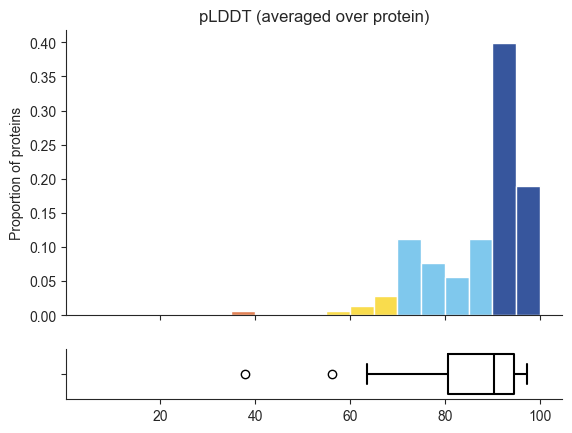

In [23]:
# plotting the pLDDT
sns.set_style("ticks", {"axes.grid" : False})
f, (ax_hist, ax_box) = plt.subplots(2, sharex = True, gridspec_kw = {"height_ratios": (.85, .15)})
plddtF = sns.histplot(x = data_plddt["avg_pLDDT"], bins = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100], 
                      stat = "proportion", ax = ax_hist)
sns.despine()
plddtF.set(title = "pLDDT (averaged over protein)", xlabel = "pLDDT", ylabel = "Proportion of proteins")
# put in AlphaFold pLDDT color scheme
for i in range(0,9):
    plddtF.patches[i].set_facecolor([0.8784, 0.5059, 0.3333])
for i in range(9,13):
    plddtF.patches[i].set_facecolor([0.9765, 0.8627, 0.3020])
for i in range(13,17):
    plddtF.patches[i].set_facecolor([0.4980, 0.7843, 0.9294])
for i in range(17,19):
    plddtF.patches[i].set_facecolor([0.2157, 0.3373, 0.6157])
sns.boxplot(data_plddt["avg_pLDDT"], ax = ax_box, orient = "h", fill = False, color = "black")
ax_box.set(xlabel = "")

Summarizing: overall, structure prediction was highly succesful, and we can use these structures for downstream analysis.

#### Goal 4: prepare necessary files for analysing protein structures of these proteins on HPC

Now that we have these protein structures, we can assess whether they are structurally similar to other proteins annotated as 'acetyltransferases'. We will do this by using FoldSeek to compare our proteins against the PDB and AlphaFold database. In order to do so, we again have to prepare jobs for the HPC. 

First, we need to copy all the relaxed structures from the predictions.

In [ ]:
os.mkdir(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison"))

In [ ]:
os.mkdir(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", "foldseek_in"))

In [24]:
for uid in list(act_unique["ncbi_protein_uid"]):
    # dealing with relaxation issue
    if uid in no_relaxed:
        # get file name/path with varable model number
        pdb = f"ncbi_uid_{uid}_unrelaxed_rank_1_model_[12345]_ptmx1.pdb"
        for file in glob.glob(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "results", f"ncbi_uid_{uid}", pdb)):
            shutil.copyfile(file,
                            os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", "foldseek_in", f"ncbi_uid_{uid}_best.pdb"))
    else:
        shutil.copyfile(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_prediction", "results", 
                                     f"ncbi_uid_{uid}", f"ncbi_uid_{uid}_relaxed.pdb"),
                        os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", "foldseek_in", f"ncbi_uid_{uid}_relaxed.pdb"))

Then, we can create the jobscript (again, based on a template), which will be submitted using job arrays, so we'll also create a datafile for this.

In [25]:
# list of input files
files = os.listdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_comparison", "foldseek_in"))
# copy template data script
shutil.copyfile(os.path.join(master_dir, "templates", "data_foldseek_5.csv"),
                os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_comparison", "foldseek_in", "data_foldseek_5.csv"))
# modify template
with open(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_comparison", "foldseek_in", "data_foldseek_5.csv"), "a+") as data_file:
    for batch in list(batched(files, 5)):
        string = ""
        for protein_pdb in batch:
            if "relaxed.pdb" in protein_pdb:
                ncbi_uid = protein_pdb.removesuffix("_relaxed.pdb")
            elif "best.pdb" in protein_pdb:
                ncbi_uid = protein_pdb.removesuffix("_best.pdb")
            aln_pdb = f"{ncbi_uid}_aln_pdb.tsv"
            aln_af50m = f"{ncbi_uid}_aln_af50m.tsv"
            string += f"{protein_pdb},{aln_pdb},{aln_af50m},"
        string = string.removesuffix(",")
        string += "\n"
        data_file.write(string)

Then we have to copy one more file, before we can transfer this to the HPC and submit our job, using atools. 

In [26]:
shutil.copyfile(os.path.join(master_dir, "templates", "script_foldseek_5.slurm"), 
                os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", "foldseek_in", "script_foldseek_5.slurm"))

'C:\\Users\\hanne\\OneDrive\\Documenten\\GitHub\\ACES-AcT\\pipeline\\1_search\\b_assess_annotated\\structure_comparison\\foldseek_in\\script_foldseek_5.slurm'

*Note: The job script and slurm output file have been post edited to remove personal information (e-mail, HPC credit, etc.).*

#### Goal 5: assess likelihood acetyltransferase function based on predicted protein structure & similar protein structures

Using the created scripts, protein structures were compared to the PDB and AlphaFold database on the HPC. To keep it all organized, the output files are moved to the folder `foldseek_out`.

While the comparison of our structure has been done, the output files are not very interpretable: matched proteins are described based on UniProt ID or PDB ID. Hence, we have to process the output to link protein names to these identifiers. 

In addition, we will also apply some quality filters to our hits. Briefly, we will filter based on:
- probability of our protein and its match to belong to the same SCOP class: > 50%
- quality of the alignment: alignment lDDT > 50% 
- likelihood of the hit: E-value cutoff E-3 (FoldSeek default)
- quality of the aligned region of input protein: average plDDT of aligned region > 70 (standard AlphaFold cut-off)

In order to do so, we write functions to extract these features, and to match the PDB/UniProt information to protein names. We fetch the latest names using the API, to get the most up-to-date information (instead of relying on the annotations stored in the database header files).

In [27]:
# functions for matching PDB and UniProt to UniProt names

# from FoldSeek target column, extract UniProt ID
def get_UniProtID_from_target(target):
    uniprot_id = target.split("-")[1]
    return uniprot_id

# from FoldSeek target column, extract PDB ID and chain
def get_PDBid_chain_from_target(target):
    pdb_id = target.split(".")[0]
    chain = target.split("_")[-1]
    return pdb_id, chain

# check if PDB ID is obsolete
def check_PDBid_active(pdb_id, obsolete_list):
    if pdb_id.upper() in obsolete_list:
        return False
    else:
        return True

# from PDB ID, get all PDB polymer entities
def get_PDB_entities_from_entry(pdb_id):
    url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb_id}"
    r = sess.get(url)
    data = json.loads(r.text)
    return data["rcsb_entry_container_identifiers"].get("polymer_entity_ids")


# match PDB entity to protein chain
def get_PDB_entity_with_chain(entity_ids,pdb_id,chain):
    for entity in entity_ids:
        url = f"https://data.rcsb.org/rest/v1/core/polymer_entity/{pdb_id}/{entity}"
        r = sess.get(url)
        data = json.loads(r.text)
        # assumption: FoldSeek gives author chain naming, not PDB renamed chain names
        if chain in data["rcsb_polymer_entity_container_identifiers"].get("auth_asym_ids"):
            return entity
        else:
            continue

# get UniProt ID based on the PDB ID and entity (corresponding to the chain reported by FoldSeek)
def get_UniProt_from_PDB_entity(pdb_id,entity):
    url = f"https://data.rcsb.org/rest/v1/core/polymer_entity/{pdb_id}/{entity}"
    r = sess.get(url)
    data = json.loads(r.text)
    return data["rcsb_polymer_entity_container_identifiers"].get("uniprot_ids")

# get protein name(s), for an array of UniProt IDs
def get_protein_name_array(uniprot_ids):
    string = ""
    if uniprot_ids == None:
        string += "WARNING This PDB entry did not have a UniProt ID associated with it"
    else:
        for pid in uniprot_ids:
            string += f"{get_protein_name_string(pid)} [UniProt ID: {pid}]"
    return string

# get protein name, for a single UniProt ID
def get_protein_name_string(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/search?query={uniprot_id}&fields=protein_name&format=tsv"
    r = sess.get(url)
    r.raise_for_status()
    content = r.text
    names = content.split("\n")[1:-1]
    # if the UniProt entry was marked as obsolete, access its UniParc accession
    if "deleted" in names:
        try:
            return ";".join([str(name) for name in get_uniparc_entry(uniprot_id)])
        except TypeError:
            return "WARNING UniProt ID is obsolete and issue with fetching UniParc information"
    else:
        return ";".join([str(name) for name in names])

# get protein names (and whether the protein is still in UniProt) from a UniParc entry matching the obsolete UniProt ID
def get_uniparc_entry(uniprot_id):
    requestURL = f"https://www.ebi.ac.uk/proteins/api/uniparc/accession/{uniprot_id}"
    r = requests.get(requestURL, headers = { "Accept" : "application/json"})
    if not r.ok:
      r.raise_for_status()
    responseBody = r.text
    data = json.loads(r.text)
    uniparc_entries = []
    uniparc_entries.append("WARNING UniProt ID obsolete, info fetched from UniParc")
    for i in range(0, len(data["dbReference"])):
        for j in data["dbReference"][i].get("property"):
            if j.get("type") == "protein_name":
                uniparc_entries.append(f"{data['dbReference'][i].get('id')} : {j.get('value')} (active UniProt ID: {data['dbReference'][i].get('active')})")
    return uniparc_entries

In [28]:
# function for calculating average pLDDT of aligned region on FoldSeek results
def get_pLDDT(structure, start, stop):
    for model in structure:
        for chain in model:
            count_residue = 0
            pLDDT_chain = 0
            for residue in chain:
                if residue.id[1] in range(start, stop + 1):
                    count_residue += 1
                    count_atom = 0
                    pLDDT_atom = 0
                    for atom in residue:
                        count_atom += 1
                        pLDDT_atom += atom.get_bfactor()
                    pLDDT_res = round(pLDDT_atom/count_atom, 2)
                    pLDDT_chain += pLDDT_res
            pLDDT_range = round(pLDDT_chain/count_residue, 2)
    return pLDDT_range

*This was executed on March 24th, 2024 (UniProt release 2024_01), and not repeated here, as protein annotations might have changed and entries in the PDB/UniProt database could have been removed since then.*

As a general note, this is definitely not the most efficient way of doing this. It is much more efficient to first make an overview of the unique PDB and/or AlphaFold database identifiers, and then query those, such as implemented in [Fold First](https://github.com/hannelorelongin/FoldFirstAskLater/tree/main).

In [ ]:
os.mkdir(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison",  "output_processed"))

In [ ]:
# instantiating a list of all obsolete PDB IDs
obsolete_ids = Bio.PDB.PDBList.get_all_obsolete(Bio.PDB.PDBList())

In [ ]:
# filtering of FoldSeek results
for uid in list(act_unique["ncbi_protein_uid"]):
    protein = f"ncbi_uid_{uid}"
    # structure file
    if uid in no_relaxed:
        structure = p.get_structure(protein, os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", 
                                                          "foldseek_in", f"{protein}_best.pdb"))
    else:
        structure = p.get_structure(protein, os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", 
                                                          "foldseek_in", f"{protein}_relaxed.pdb"))
    # analyzing AlphaFold hits
        # reading in the data
    data_af50m = pd.read_table(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", "foldseek_out", f"{protein}_aln_af50m.tsv"), 
                               header = None, names = ["query", "target", "fident", "alnlen", "mismatch", "gapopen", "qstart", "qend", 
                                                       "tstart", "tend", "evalue", "bits", "prob", "lddt", "lddtfull"])
        # adding AlphaFold quality metrics - pLDDT of aligned region query
    for i in range(0, len(data_af50m)):
        data_af50m.at[i, "pLDDT_qAln"] = get_pLDDT(structure, data_af50m.at[i, "qstart"], data_af50m.at[i, "qend"])
        # filtering based on FoldSeek parameters & AF model accuracy
    data_af50m_filtered = data_af50m
    if len(data_af50m_filtered) != 0:
        data_af50m_filtered = data_af50m_filtered[(data_af50m_filtered["prob"] > 0.5) & (data_af50m_filtered["evalue"] < 1e-3) 
            & (data_af50m_filtered["lddt"] >= 0.5) & (data_af50m_filtered["pLDDT_qAln"] >= 0.7)]
    data_af50m_filtered_annotated = data_af50m_filtered.reset_index()
    if len(data_af50m_filtered_annotated) != 0:
        for i in range(0, len(data_af50m_filtered_annotated)):
            data_af50m_filtered_annotated.at[i, "protein_descr"] = get_protein_name_string(get_UniProtID_from_target(
                data_af50m_filtered_annotated.at[i, "target"]))
        # store results
    data_af50m_filtered_annotated.to_csv(os.path.join(pipeline_search_dir, "b_assess_annotated", "structure_comparison", "output_processed",
                                                      f"{protein}_foldseek_af50m_processed.tsv"), sep = "\t", index = False)     
    # analyzing PDB hits
        # reading in the data
    data_pdb = pd.read_table(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", "foldseek_out", f"{protein}_aln_pdb.tsv"), 
                             header = None, names = ["query", "target", "fident", "alnlen", "mismatch", "gapopen",
                                                     "qstart", "qend", "tstart", "tend", "evalue", "bits", "prob", "lddt", "lddtfull"])
        # adding AlphaFold quality metrics - pLDDT of aligned region query
    for i in range(0, len(data_pdb)):
        data_pdb.at[i,"pLDDT_qAln"] = get_pLDDT(structure, data_pdb.at[i, "qstart"], data_pdb.at[i, "qend"])
        # filtering based on FoldSeek parameters & AF model accuracy
    data_pdb_filtered = data_pdb
    if len(data_pdb_filtered) != 0:
        data_pdb_filtered = data_pdb_filtered[(data_pdb_filtered["prob"] > 0.5) & (data_pdb_filtered["evalue"] < 1e-3) &
            (data_pdb_filtered["lddt"] >= 0.5) & (data_pdb_filtered["pLDDT_qAln"] >= 0.7)]
    data_pdb_filtered_annotated = data_pdb_filtered.reset_index()
    if len(data_pdb_filtered_annotated) != 0:
        for i in range(0, len(data_pdb_filtered_annotated)):
            pdb_id, chain = get_PDBid_chain_from_target(data_pdb_filtered_annotated.at[i, "target"])
            if check_PDBid_active(pdb_id, obsolete_ids):
                data_pdb_filtered_annotated.at[i, "protein_descr"] = get_protein_name_array(get_UniProt_from_PDB_entity(pdb_id,get_PDB_entity_with_chain(get_PDB_entities_from_entry(pdb_id), pdb_id,chain)))
            else:
                data_pdb_filtered_annotated.at[i, "protein_descr"] = "WARNING This PDB ID is obsolete, hence, no information could be fetched"
        # store filtered FoldSeek results
    data_pdb_filtered_annotated.to_csv(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", "output_processed",
                                                    f"{protein}_foldseek_pdb_processed.tsv"), sep = "\t", index = False) 

Let's read in the data as obtained in March 2024, and use it. Now that all hits have been named, we can start investigating if proteins matched to our query match other acetyltransferases. Again, we will look for 'acetyltransferase' annotations. 

In [29]:
# loop over the different proteins
for index, row in act_unique.iterrows():
    uid = row["ncbi_protein_uid"]
    protein = f"ncbi_uid_{uid}"
    # set counts to 0 for every new protein
    count_acetyltransferase_pdb = 0
    count_acetyltransferase_af = 0
    # read in data
    pdb_annotations = pd.read_csv(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", "output_processed", 
                                               f"{protein}_foldseek_pdb_processed.tsv"), sep = "\t")
    af_annotations =  pd.read_csv(os.path.join(pipeline_search_dir,  "b_assess_annotated", "structure_comparison", "output_processed",
                                               f"{protein}_foldseek_af50m_processed.tsv"), sep = "\t")
    # if annotations present, count ones containing "acetyltransferase"
    if pdb_annotations.shape[1] == 18:
        count_acetyltransferase_pdb = len(pdb_annotations[pdb_annotations["protein_descr"].str.contains("acetyltransferase", case = False)])
    if af_annotations.shape[1] == 18:
        count_acetyltransferase_af = len(af_annotations[af_annotations["protein_descr"].str.contains("acetyltransferase", case = False)])
    # assign data to dataframe
    act_unique.loc[index, "count_act_pdb"] = int(count_acetyltransferase_pdb)
    act_unique.loc[index, "count_act_af"] =  int(count_acetyltransferase_af)

C:\Users\hanne\AppData\Local\Temp\ipykernel_17648\931273040.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_unique.loc[index, "count_act_pdb"] = int(count_acetyltransferase_pdb)
C:\Users\hanne\AppData\Local\Temp\ipykernel_17648\931273040.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_unique.loc[index, "count_act_af"] =  int(count_acetyltransferase_af)


##### Manual inspection of proteins with no matches to acetyltransferases in PDB and AlphaFold database

First, we will look into proteins that do not match any of the acetyltransferase structures in the PDB and the AlphaFold database.

In [30]:
# let's look into those lacking acetyltransferase annotation from both PDB and AlphaFold database
act_unique[(act_unique["count_act_af"] == 0) & (act_unique["count_act_pdb"] == 0)]

,sequence,length,virus_name,virus_taxid,name_taxid,virus_lineage,host_name,host_lineage,ncbi_protein_uid,ncbi_protein_name,uniprot_protein_id,uniprot_protein_name,count_act_pdb,count_act_af
5,MAQAPVTGQYPSEKNTPALTLPFSKSVKGVPITKANLDDPAHPINI...,220,Pseudomonas phage Achelous,2163982,Achelous_taxid_2163982,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas syringae pv. avii'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1842013527,acetyl-CoA acetyltransferase [Pseudomonas phag...,NaN,NaN,0.0,0.0
6,MATPPNIIGDIKDHKEVLKEGVTLHNMPVVLAASLLNKAHVINERN...,91,Pseudomonas phage Achelous,2163982,Achelous_taxid_2163982,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas syringae pv. avii'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1842013526,acetyl-CoA acetyltransferase [Pseudomonas phag...,NaN,NaN,0.0,0.0
13,MAQAPNIIGDQKSHKDVQKYGVTLHNMPVVAEALLTAKGSVLNDHV...,91,Pseudomonas phage Alpheus,2163983,Alpheus_taxid_2163983,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas syringae pv. avii'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1842013578,acetyl-CoA acetyltransferase [Pseudomonas phag...,NaN,NaN,0.0,0.0
30,MREHDFPSCCTAKIYTGMGPSGTADYQSIRDSEGFSPKKFAMDVLQ...,137,Pseudomonas phage HZ2201,3050367,HZ2201_taxid_3050367,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas aeruginosa PAO1'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,2512504421,N-acetyltransferase [Pseudomonas phage HZ2201],NaN,NaN,0.0,0.0
33,MREHNFPSCCTAKIYTGMGPTSTADYQSIKDSEGFSPKKFAMDVIQ...,136,Pseudomonas phage Ka1,2982899,Ka1_taxid_2982899,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,2347445589,N-acetyltransferase [Pseudomonas phage Ka1],A0A9E8GCV0,N-acetyltransferase,0.0,0.0
38,MVKPTHFVKPALAAAGAQEYALCIKLEEDGDLTAWGDTNSNFLFYT...,131,Pseudomonas phage Lu11,1161927,Lu11_taxid_1161927,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas putida'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,383389569,hypothetical protein Lu11_0013 [Pseudomonas ph...,I1TQ14,N-acetyltransferase domain-containing protein,0.0,0.0
49,MKKDNSNSIPTFSEEQYKYLAQSFPAMVIQHTHTLSEVMLGAGEQR...,67,Pseudomonas phage MR12,2711176,MR12_taxid_2711176,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1834462876,putative GNAT family N-acetyltransferase [Pseu...,A0A6M3TDD1,Putative GNAT family N-acetyltransferase,0.0,0.0
53,MPRNITGDSPKSVQTQSVSMLPVAIVTQADLASAAHPINDTTKSGK...,92,Pseudomonas phage MR4,2711171,MR4_taxid_2711171,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1834462578,putative acetyltransferase [Pseudomonas phage ...,A0A6M3T931,Putative acetyltransferase,0.0,0.0
59,MATSVTGDLKDHKDVQKKGVTLHNMPVYPLAELSAVGSVLNDRVVS...,89,Pseudomonas phage Nerthus,2163984,Nerthus_taxid_2163984,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas syringae pv. avii'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1842013476,acetyl-CoA acetyltransferase [Pseudomonas phag...,NaN,NaN,0.0,0.0
62,MANVTGEYPEDRLIPALTVPFTKTQKGAAVVAANLQDPNHPINISN...,210,Pseudomonas phage Njord,2163985,Njord_taxid_2163985,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas syringae pv. avii'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1842013431,acetyl-CoA acetyltransferase [Pseudomonas phag...,NaN,NaN,0.0,0.0


Based on our manual inspection (Excel file `manual_assessment.xlsx`, sheet `assessment_no_hits`), the proteins for which no structurally similar annotated 'acetyltransferase' was found by FoldSeek, are indeed not acetyltransferases. 

##### Manual inspection of proteins with no matches to acetyltransferases in PDB, but with matches in AlphaFold database

We will also look into the proteins for which we found structural similarity with acetyltransferases in the AlphaFold database, but not in the PDB.

In [31]:
# let's look into those lacking acetyltransferase annotation from PDB, but not from AlphaFold database
act_unique[(act_unique["count_act_af"] != 0) & (act_unique["count_act_pdb"] == 0)]

,sequence,length,virus_name,virus_taxid,name_taxid,virus_lineage,host_name,host_lineage,ncbi_protein_uid,ncbi_protein_name,uniprot_protein_id,uniprot_protein_name,count_act_pdb,count_act_af
4,MSEKGYIVAVTPYVKQSQKYMKKPEMTYEFISHTDRKRYIQFAHQA...,199,Pseudomonas phage 201phi2-1,198110,201phi2-1_taxid_198110,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas chlororaphis'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,164609589,hypothetical protein 201phi2-1p373 [Pseudomona...,B3FJN3,N-acetyltransferase domain-containing protein,0.0,3.0
37,MIFLLHTSPESVRHAASFLCHQNLYEKIGNLRYVWPELASVGTYRK...,187,Pseudomonas phage Lu11,1161927,Lu11_taxid_1161927,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas putida'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,383389898,hypothetical protein Lu11_0335 [Pseudomonas ph...,I1TQZ3,N-acetyltransferase domain-containing protein,0.0,3.0
75,MSQYPNYGLSFVVTDTVEGNRGSALTGLLYQMHEPNGQLVLDYRRL...,198,Pseudomonas phage Phabio,2006668,Phabio_taxid_2006668,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas fluorescens SBW25'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1199937949,hypothetical protein PHABIO_371 [Pseudomonas p...,A0A1Y0SU30,N-acetyltransferase domain-containing protein,0.0,3.0
81,MGMNVNSGIRISSGYKPFIDGLRALSILAVVLYHAGVPMVYGGFVG...,687,Pseudomonas phage PMG1,2992927,PMG1_taxid_2992927,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas aeruginosa'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,371767363,O-polysaccharide acetyltransferase protein [Ps...,NaN,NaN,0.0,84.0
104,MSNPTVKYRPEIDGLRAIAVLSVILFHAGFKSFSGGFVGVDVFFVI...,642,Pseudomonas phage vB_PaeP_Tr60_Ab31,1449437,vB_PaeP_Tr60_Ab31_taxid_1449437,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas aeruginosa'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,585865417,Putative peptidoglycan O-acetyltransferase [Ps...,W6MVL2,Putative peptidoglycan O-acetyltransferase,0.0,70.0
106,MSNPTVKYRPEIDGLRAIAVLSVILFHAGFKSFSGGFVGVDVFFVI...,642,Pseudomonas phage vB_PaeP_YA3,2588095,vB_PaeP_YA3_taxid_2588095,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas aeruginosa UCBPP-PA14'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1682780652,O-polysaccharide acetyltransferase protein [Ps...,A0A4Y5TNI7,O-polysaccharide acetyltransferase protein,0.0,74.0
129,MNTEDILIERDDAARPRFSLMDNMRVERGTKADWDALHDLHYKAEN...,291,Pseudomonas phage hairong,2912595,hairong_taxid_2912595,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas syringae pv. actinidiae'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,2190146464,hypothetical protein hairong_006 [Pseudomonas ...,A0A9E7CC04,N-acetyltransferase domain-containing protein,0.0,95.0
141,MSQPEWEIVVERNDQAKPRFSLLDTMRVEPGTKADWDELHDLHYKA...,293,Pseudomonas phage nickie,2048977,nickie_taxid_2048977,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas syringae pv. avii'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,1278224063,hypothetical protein CNR34_00010 [Pseudomonas ...,A0A2H4P6X5,N-acetyltransferase,0.0,94.0
144,MMEAIRQFIETQRTASHTRSLWFEDHNIHIYLRAGEYHLDVETRQW...,121,Pseudomonas phage PaBG,1335230,PaBG_taxid_1335230,Viruses; Duplodnaviria; Heunggongvirae; Urovir...,['Pseudomonas aeruginosa PAO1'],['Bacteria; Pseudomonadota; Gammaproteobacteri...,529282538,hypothetical protein PaBG_00010 [Pseudomonas p...,S5VM23,N-acetyltransferase domain-containing protein,0.0,19.0


Based on this manual inspection,  (Excel file `manual_assessment.xlsx`, sheet `assessment_hits_1_database`) it does appear that all of these proteins could be acetyltransferases. Hence, there is value in searching both the PDB and the AlphaFold database.

In the end, our annotated acetyltransferase dataset contains 23 (unique) likely wrongfully annotated proteins. Let's remove those (and their 100% identical homologs) from our acetyltransferase dataset.

In [32]:
sequences_act_notverified = list(act_unique[(act_unique["count_act_af"] == 0) & (act_unique["count_act_pdb"] == 0)]["sequence"])
act_verified = act_overview[acetyltransferases["sequence"].isin(sequences_act_notverified)  == False].reset_index(drop = True)

##### Overview of the remaining dataset

In [33]:
# some statistics on the new dataset
    # number of acetyltransferases
number_act_left = len(act_verified)
number_removed = len(act_overview) - number_act_left
number_act_left_unique = len(act_verified["sequence"].unique())
    # number of viruses
number_phages = len(act_verified["virus_name"].unique())
    # acetyltransferases per virus
act_verified_per_phage = act_verified.groupby("virus_name", as_index = False).size()
number_single_act = len(act_verified_per_phage[act_verified_per_phage["size"] == 1])
number_two_act = len(act_verified_per_phage[act_verified_per_phage["size"] == 2])
number_over_two_act = len(act_verified_per_phage[act_verified_per_phage["size"] > 2])
    # acetyltransferase size
avg_size = act_verified["length"].mean()
min_size = act_verified["length"].min()
max_size = act_verified["length"].max()
number_below_100aa = len(act_verified[act_verified["length"] < 100])
number_over_300aa = len(act_verified[act_verified["length"] > 300])
# printing stats
print(f"After verification, {number_removed} acetyltransferases were deemed wrongfully annotated, leaving us with {number_act_left} acetyltransferases.")
print(f"Of these {number_act_left} acetyltransferases, {number_act_left_unique} are unique proteins (based on sequence).")
print(f"These {number_act_left} acetyltransferases were found in {number_phages} different phages.")
print(f"{number_single_act} phages contain 1 annotated acetyltransferase, {number_two_act} phages contain 2, and {number_over_two_act} phages contain more than 2 annotated acetyltransferases.")
print(f"The average size of these acetyltransferases is {avg_size} amino acids, with a minimum of {min_size} amino acids.")
print(f"Although the minimum size is {min_size} amino acids, only {number_below_100aa} acetyltransferases are smaller than 100 amino acids.")
print(f"The largest size is {max_size} amino acids, but only {number_over_300aa} acetyltransferases are larger than 300 amino acids.")

After verification, 24 acetyltransferases were deemed wrongfully annotated, leaving us with 189 acetyltransferases.
Of these 189 acetyltransferases, 120 are unique proteins (based on sequence).
These 189 acetyltransferases were found in 147 different phages.
109 phages contain 1 annotated acetyltransferase, 36 phages contain 2, and 2 phages contain more than 2 annotated acetyltransferases.
The average size of these acetyltransferases is 162.42857142857142 amino acids, with a minimum of 64 amino acids.
Although the minimum size is 64 amino acids, only 2 acetyltransferases are smaller than 100 amino acids.
The largest size is 687 amino acids, but only 3 acetyltransferases are larger than 300 amino acids.


#### Goal 6 : investigate smaller-than-expected annotated acetyltransferases

##### General description

Interestingly, of the 23 unique proteins we removed, 11 were smaller than 100 amino acids, leaving only two annotated acetyltransferases below this cutoff. Let's check these ones out.

- ncbi_uid_1774219721:
    - length: 64 amino acids
    - PDB hits: 39, all acetyltransferases
    - AFdb hits: 1053, 1019 acetyltransferase
    - annotation evidence: Pfam, InterPro, 100% sequence match to C-term half of *Pseudomonas aeruginosa* acetyltransferase B3G173 (total size: 158 AA)
    - conclusion: perfect match to 50% (= C-terminus) of an acetyltransferase, perhaps missed earlier start codon?

- ncbi_uid_425702522:
    - length: 94 amino acids
    - PDB hits: 67, all acetyltransferases
    - AFdb hits: 811, nearly all acetyltransferases
    - annotation evidence: Pfam, InterPro
    - conclusion: matches very well to existing acetyltransferases, but lacks first N-terminal residues, perhaps missed earlier start codon or a minimal form?

Conclusion: They both appear to be GNATs, that lack some N-terminal residues. 

##### Investigating the presence of earlier (in-frame) start codons

Let's check if there is an earlier start codon ahead using EXPASY translate (through its webportal). 

The input (a wide range of DNA sequence around the encoded acetyltransferase) is stored in `investigate_early_start`/`expasy_translate`. [EXPASY translate](https://web.expasy.org/translate/) is used with 'standard genetic code' and 'Forward' and 'Reverse' strand selected. The output is stored in the file `translate.txt`. 

For ncbi_uid_1774219721, an in-frame (3'5' frame 2) longer variant (158 amino acids) is identified. 

For ncbi_uid_425702522, an in-frame (5'3' frame 3) longer variant (179 amino acids) is identified. 

Both could thus potentially be larger proteins, by extending at the N-terminus. Let's run these sequences through our AlphaFold-FoldSeek pipeline too.

##### Structure-based assessment of elongated variants

First, we have to predict the protein structures using VIBFold:

In [ ]:
# create directory for structure prediction
os.mkdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction"))
os.mkdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction", "fastas"))

In [34]:
# template job script
template = os.path.join(master_dir, "templates", "submit_vibfold.py")
# loop over proteins
for uid in os.listdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "expasy_translate")):
    seq = str(SeqIO.read(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "expasy_translate", uid, "translate.txt"), 
                     "fasta").seq)
    # creating fasta file 
    with open(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction", "fastas",
                           f"{uid}_elongated.fasta"), "w") as file:
        file.write(f">{uid}_elongated\n")
        file.write(f"{seq}\n")
    # adapt job script
    out_path = os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction",
                            f"submit_vibfold_{uid}_elongated.py")
    adapt_vibfold_jobscript(template, f"{uid}_elongated.fasta", out_path, len(seq))
# copy necessary scripts
shutil.copyfile(os.path.join(master_dir, "templates", "VIBFold.py"),
                os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction", "VIBFold.py"))
shutil.copyfile(os.path.join(master_dir, "templates", "VIBFold_adapted_functions.py"),
                os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction", 
                             "VIBFold_adapted_functions.py"))

'C:\\Users\\hanne\\OneDrive\\Documenten\\GitHub\\ACES-AcT\\pipeline\\1_search\\b_assess_annotated\\investigate_early_starts\\structure_prediction\\VIBFold_adapted_functions.py'

We can now upload these files to the HPC and submit the jobs. 

Let's investigate the quality of the predicted protein structures:

In [35]:
# results storage dict
protein_plddt_long = {}
# looping over proteins
for uid in os.listdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "expasy_translate")):
    structure = p.get_structure(uid, os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction", 
                                                  "results", f"{uid}_elongated", f"{uid}_elongated_relaxed.pdb"))
    # actually calculate average pLDDT
    protein_plddt_long[uid] = avg_pLDDT(structure)

In [36]:
# the data for pLDDT analysis
data_plddt_long = pd.DataFrame(data = protein_plddt_long.items(), columns = ["ncbi_protein_uid", "avg_pLDDT"])

In [37]:
# some statistics on the pLDDT
avg_plddt_long = "{:.2f}".format(np.mean(data_plddt_long["avg_pLDDT"]))
std_plddt_long = "{:.2f}".format(np.std(data_plddt_long["avg_pLDDT"]))
med_plddt_long = np.median(data_plddt_long["avg_pLDDT"])
min70_num_long = len(data_plddt_long[data_plddt_long["avg_pLDDT"] >= 70])
pct_ok_plddt_long = "{:.2f}".format(min70_num_long/len(data_plddt_long)*100)
print(f"On average, the pLDDT score for structures predicted for our (elongated) proteins is {avg_plddt_long} +- {std_plddt_long} (median: {med_plddt_long}).")
print(f"The pLDDT score for structures predicted for {min70_num_long} out of our {len(data_plddt_long)} (elongated) proteins ({pct_ok_plddt_long}%) is at least 70, which is used as a general cut-off for trustworthy structure predictions.")

On average, the pLDDT score for structures predicted for our (elongated) proteins is 83.56 +- 12.88 (median: 83.565).
The pLDDT score for structures predicted for 2 out of our 2 (elongated) proteins (100.00%) is at least 70, which is used as a general cut-off for trustworthy structure predictions.


Now, we can prepare everything for the FoldSeek search.

In [ ]:
os.mkdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_comparison"))
os.mkdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_comparison", "foldseek_in"))

In [38]:
# preparing structure comparison of longer variants
for uid in os.listdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "expasy_translate")):
    # copy relevant files
    shutil.copyfile(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction", "results", 
                                 f"{uid}_elongated", f"{uid}_elongated_relaxed.pdb"),
                    os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_comparison", "foldseek_in",
                                 f"{uid}_elongated_relaxed.pdb"))

In [39]:
script_content_foldseek_2 = '''#!/bin/bash

#SBATCH --nodes=1 --ntasks-per-node=24
#SBATCH --time=01:30:00

cd $SLURM_SUBMIT_DIR
export OMP_PROC_BIND=false

source /data/leuven/331/vsc33164/miniconda3/bin/activate
conda activate foldseekEnv

pdb_db="/staging/leuven//stg_00144/foldseek_db/pdb_2024mar"
af50m_db="/staging/leuven//stg_00144/foldseek_db/af50m_2024mar"

foldseek easy-search \
$relaxed_pdb_1 \
$pdb_db \
$output_pdb_1 \
$TMPDIR \
--format-output "query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,prob,lddt,lddtfull"

foldseek easy-search \
$relaxed_pdb_1 \
$af50m_db \
$output_af50m_1 \
$TMPDIR \
--format-output "query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,prob,lddt,lddtfull"

foldseek easy-search \
$relaxed_pdb_2 \
$pdb_db \
$output_pdb_2 \
$TMPDIR \
--format-output "query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,prob,lddt,lddtfull"

foldseek easy-search \
$relaxed_pdb_2 \
$af50m_db \
$output_af50m_2 \
$TMPDIR \
--format-output "query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,prob,lddt,lddtfull"

'''

In [40]:
for index, uid in enumerate(os.listdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "expasy_translate"))):
    script_content_foldseek_2 = script_content_foldseek_2.replace(f"$relaxed_pdb_{index + 1}", f"{uid}_elongated.pdb")
    script_content_foldseek_2 = script_content_foldseek_2.replace(f"$output_pdb_{index + 1}", f"{uid}_elongated_aln_pdb.tsv")
    script_content_foldseek_2 = script_content_foldseek_2.replace(f"$output_af50m_{index + 1}", f"{uid}_elongated_aln_af50m.tsv")

In [41]:
script =  os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_comparison", "foldseek_in",
                       "script_foldseek_2.slurm")
with open(script, "w") as file:
    print(script_content_foldseek_2, file = file)

Now we can put these files on the HPC to run. Again, the output is stored in `foldseek_out`, and the slurm.out file post-edited for privacy reasons. Now, we can analyse the FoldSeek results as before.

*This was executed on March 28th, 2024 (UniProt release 2024_01), and not repeated here, as protein annotations might have changed and entries in the PDB/UniProt database could have been removed since then.*

In [ ]:
os.mkdir(os.path.join(pipeline_search_dir,  "b_assess_annotated", "investigate_early_starts", "structure_comparison", "output_processed"))

In [ ]:
# overview of all proteins
protein_set = os.listdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "expasy_translate"))

# filtering of FoldSeek results
for protein in protein_set:
    structure = p.get_structure(uid, os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "structure_prediction", 
                                                  "results", f"{protein}_elongated", f"{protein}_elongated_relaxed.pdb"))
    # analyzing AlphaFold hits
        # reading in the data
    data_af50m = pd.read_table(os.path.join(pipeline_search_dir,  "b_assess_annotated", "investigate_early_starts", "structure_comparison", 
                                            "foldseek_out", f"{protein}_elongated_aln_af50m.tsv"), 
                               header = None, names = ["query", "target", "fident", "alnlen", "mismatch", "gapopen", "qstart", "qend", 
                                                       "tstart", "tend", "evalue", "bits", "prob", "lddt", "lddtfull"])
        # adding AlphaFold quality metrics - pLDDT of aligned region query
    for i in range(0, len(data_af50m)):
        data_af50m.at[i, "pLDDT_qAln"] = get_pLDDT(structure, data_af50m.at[i, "qstart"], data_af50m.at[i, "qend"])
        # filtering based on FoldSeek parameters & AF model accuracy
    data_af50m_filtered = data_af50m
    if len(data_af50m_filtered) != 0:
        data_af50m_filtered = data_af50m_filtered[(data_af50m_filtered["prob"] > 0.5) & (data_af50m_filtered["evalue"] < 1e-3) 
            & (data_af50m_filtered["lddt"] >= 0.5) & (data_af50m_filtered["pLDDT_qAln"] >= 0.7)]
    data_af50m_filtered_annotated = data_af50m_filtered.reset_index()
    if len(data_af50m_filtered_annotated) != 0:
        for i in range(0, len(data_af50m_filtered_annotated)):
            data_af50m_filtered_annotated.at[i, "protein_descr"] = get_protein_name_string(get_UniProtID_from_target(
                data_af50m_filtered_annotated.at[i, "target"]))
        # store results
    data_af50m_filtered_annotated.to_csv(os.path.join(pipeline_search_dir, "b_assess_annotated",  "investigate_early_starts", "structure_comparison", 
                                                      "output_processed", f"{protein}_elongated_foldseek_af50m_processed.tsv"), sep = "\t", index = False)     
    # analyzing PDB hits
        # reading in the data
    data_pdb = pd.read_table(os.path.join(pipeline_search_dir,  "b_assess_annotated", "investigate_early_starts", "structure_comparison", 
                                          "foldseek_out", f"{protein}_elongated_aln_pdb.tsv"), 
                             header = None, names = ["query", "target", "fident", "alnlen", "mismatch", "gapopen",
                                                     "qstart", "qend", "tstart", "tend", "evalue", "bits", "prob", "lddt", "lddtfull"])
        # adding AlphaFold quality metrics - pLDDT of aligned region query
    for i in range(0, len(data_pdb)):
        data_pdb.at[i,"pLDDT_qAln"] = get_pLDDT(structure, data_pdb.at[i, "qstart"], data_pdb.at[i, "qend"])
        # filtering based on FoldSeek parameters & AF model accuracy
    data_pdb_filtered = data_pdb
    if len(data_pdb_filtered) != 0:
        data_pdb_filtered = data_pdb_filtered[(data_pdb_filtered["prob"] > 0.5) & (data_pdb_filtered["evalue"] < 1e-3) &
            (data_pdb_filtered["lddt"] >= 0.5) & (data_pdb_filtered["pLDDT_qAln"] >= 0.7)]
    data_pdb_filtered_annotated = data_pdb_filtered.reset_index()
    if len(data_pdb_filtered_annotated) != 0:
        for i in range(0, len(data_pdb_filtered_annotated)):
            pdb_id, chain = get_PDBid_chain_from_target(data_pdb_filtered_annotated.at[i, "target"])
            if check_PDBid_active(pdb_id, obsolete_ids):
                data_pdb_filtered_annotated.at[i, "protein_descr"] = get_protein_name_array(get_UniProt_from_PDB_entity(pdb_id,get_PDB_entity_with_chain(get_PDB_entities_from_entry(pdb_id), pdb_id,chain)))
            else:
                data_pdb_filtered_annotated.at[i, "protein_descr"] = "WARNING This PDB ID is obsolete, hence, no information could be fetched"
        # store filtered FoldSeek results
    data_pdb_filtered_annotated.to_csv(os.path.join(pipeline_search_dir,  "b_assess_annotated", "investigate_early_starts", "structure_comparison", 
                                                    "output_processed", f"{protein}_elongated_foldseek_pdb_processed.tsv"), sep = "\t", index = False) 

When inspecting the FoldSeek results from March '24, we can see that for protein with NCBI protein unique idenitifier 1774219721 there is a 7-fold increase in matched proteins from the PDB, +- all acetyltransferases. The number of matched hits from the AlphaFold database increased slightly. There is also a nearly identical match to a *Pseudomonas aeruginosa* acetyltransferase. Although it would be odd for a phage to contain an exact copy of a host gene, it is possible that this gene is actually encoded by a prophage. Based on all this evidence, we conclude that the elongated version of this acetyltransferase falls more in line with the expectations of an acetyltransferase, and it is possible that the shorter variant was misannotated.

For protein with NCBI protein unique identifier 425702522 there is a 5-fold decrease in matched proteins from the PDB, +- all acetyltransferases. The number of matched hits from the AlphaFold database decreased slightly. However, many other phages of the phiKMV genus appear to be encoding a homolog of the longer variant, which makes the long variant likely. It appears that this is a homolog of our very own [LUZ19 Gp13](https://doi.org/10.1128/mbio.00061-13).

After all these verifications, we can now create a **final overview table with all the assessed acetyltransferases: assessed_annotated_acetyltransferases_overview.tsv**. We will keep the two proteins that were potentially annotated too short, but also add their longer counterpart to the table and our downstream analyses.

In [42]:
# create new column to identify elongated variants - binary variable: True = elongated, False = original
act_verified["elongated"] = False
# append the two rows with the elongated variants
    # first copy
uids_extend = os.listdir(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "expasy_translate"))
for uid in uids_extend:
    seq = str(SeqIO.read(os.path.join(pipeline_search_dir, "b_assess_annotated", "investigate_early_starts", "expasy_translate", uid, "translate.txt"), 
                         "fasta").seq)
    act_verified_ext = act_verified[act_verified["ncbi_protein_uid"] == int(uid.split("_")[-1])].copy()
    act_verified_ext["sequence"] = seq
    act_verified_ext["length"] = len(seq)
    act_verified_ext["elongated"] = True
    act_verified_ext["modeled_identical_ncbi_protein_uid"] = f"{uid.split('_')[-1]}_elongated"
    act_verified = pd.concat([act_verified, act_verified_ext], ignore_index = True)

In [43]:
# store results
act_verified.to_csv(os.path.join(pipeline_search_dir, "b_assess_annotated", "assessed_annotated_acetyltransferases.tsv"), sep = "\t", index = False)